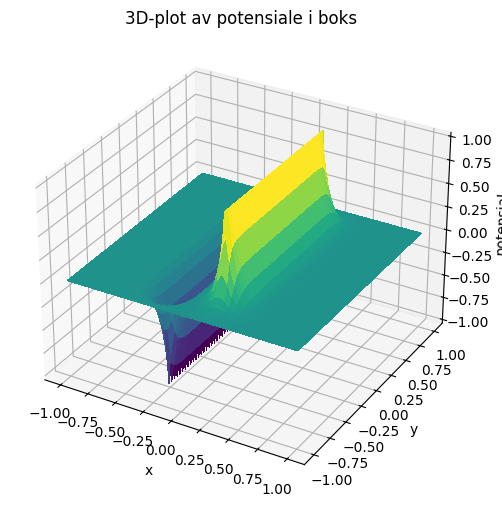

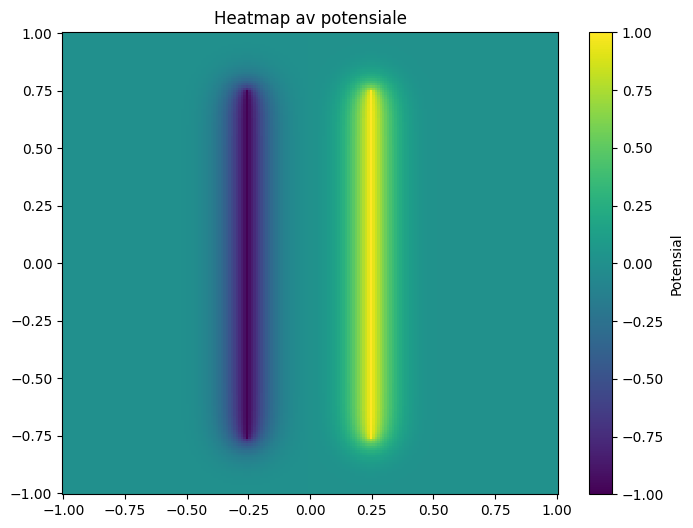

In [ ]:
#jeg finner ikke ut av hvordan man legger til sånn fancy overskrifter og titler i jupyter notebooks. Tilgi meg, kjære du som retter. Jeg er bare et menneske.

#OPPGAVE a)


import matplotlib.pyplot as plt 
import numpy as np 
from matplotlib import cm 
xv = np.linspace(-1,1,200)
yv = np.linspace(-1,1,200)
X,Y = np.meshgrid(xv, yv)
N=200

#lager en initialgjetning
V0 = np.zeros((N, N))

x_indeks_venstre = 74
x_indeks_hoyre = 200-75-1
y_indeks_bunn = 200-25-1
y_indeks_topp = 24

def laplaceloser(V, iterasjoner=500):
    for k in range(iterasjoner):
        V[1:-1, 1:-1] = .25 * (V[:-2, 1:-1] + V[2:,1:-1] + V[1:-1,:-2]+V[1:-1,2:]) #vanlig gauss seidel
    #vi må tvinge randbetingelsene
        V[y_indeks_topp:y_indeks_bunn+1, x_indeks_hoyre]=1
        V[y_indeks_topp:y_indeks_bunn+1, x_indeks_venstre]=-1
    #den andre randbetingelsen om å holde veggene på null er jo grei siden vi ikke oppdaterer dem i iterasjonene
    return V
Vk = laplaceloser(V0,N)


fig  = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
plt.title("3D-plot av potensiale i boks")
plt.xlabel("x")
plt.ylabel("y")
ax.set_zlabel("potensial")

surf = ax.plot_surface(X,Y,Vk, cmap = cm.viridis, linewidth=0,antialiased = False)


plt.figure(figsize=(8,6))
plt.pcolormesh(X,Y,Vk,shading='auto', cmap='viridis')
plt.colorbar(label='Potensial')
plt.title('Heatmap av potensiale')
plt.show()
plt.show()



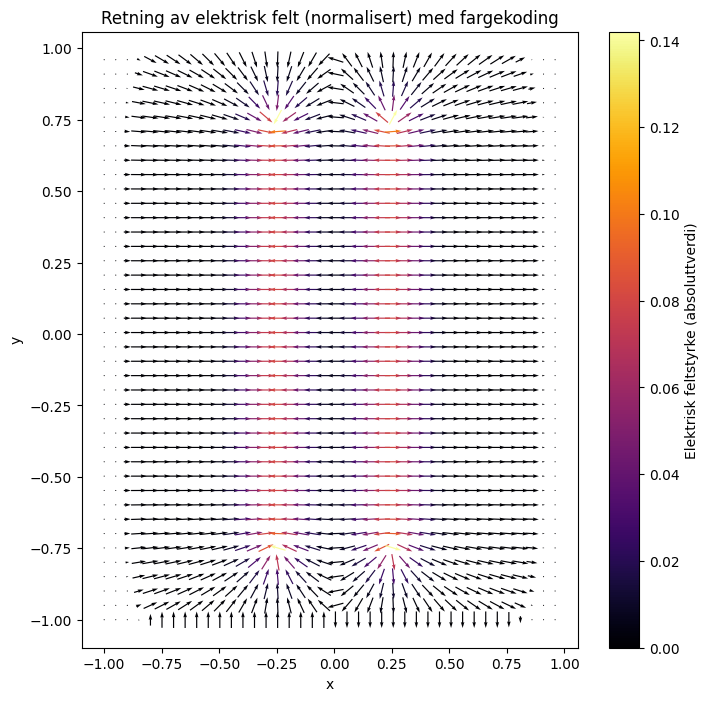

In [2]:
#OPPGAVE B

# Beregn gradienten til potensialet
Ey, Ex = np.gradient(-Vk) 

#Beregn lengde av hver vektor
magnitude = np.sqrt(Ex**2 + Ey**2)

# Normaliser vektorene (unngår nulldivisionerror ved å legge til en veldig liten korrigering)
Ex_norm = Ex / (magnitude + 1e-10)
Ey_norm = Ey / (magnitude + 1e-10)

plt.figure(figsize=(8,8))
skip = (slice(None, None, 5), slice(None, None, 5))
plt.quiver(X[skip], Y[skip], Ex_norm[skip], Ey_norm[skip], magnitude[skip], 
           cmap='inferno', pivot='mid', scale=30)

plt.colorbar(label='Elektrisk feltstyrke (absoluttverdi)')
plt.title('Retning av elektrisk felt (normalisert) med fargekoding')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

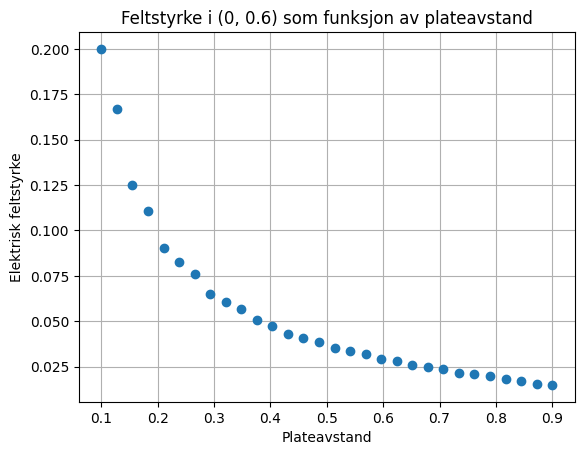

In [4]:
#OPPGAVE C

#finner de relevante indeksene for platene
def indekser(d):
    mid = N//2
    avstand = int(round((d/2.0)*(N/2.0)))

    x_h = mid+avstand
    x_v = mid-avstand
    return int(x_h), int(x_v)

d_list = np.linspace(0.1, 0.9, 30)

def laplaceloser2(V,d,iterasjoner=2000): #øker iterasjoner for bedre konvergens.
    
    x_h,x_v = indekser(d)
    for k in range(iterasjoner):
        V[1:-1, 1:-1] = .25 * (V[:-2, 1:-1] + V[2:,1:-1] + V[1:-1,:-2]+V[1:-1,2:]) #vanlig gauss seidel
    #vi må tvinge randbetingelsene
        V[y_indeks_topp:y_indeks_bunn+1, x_h]=1
        V[y_indeks_topp:y_indeks_bunn+1, x_v]=-1
    #den andre randbetingelsen om å holde veggene på null er jo grei siden vi ikke oppdaterer dem i iterasjonene
    return V
#indeks for (0, 0.6)
observasjons_x = 100
observasjons_y = 160




d_results = []
for d in d_list:
    V_init = np.zeros((N,N))
    v_out = laplaceloser2(V_init,d)
    feltx, felty = np.gradient(v_out)
    value = np.sqrt(feltx[observasjons_y][observasjons_x]**2+felty[observasjons_y][observasjons_x]**2)
    d_results.append(value)

plt.plot(d_list,d_results, 'o')
plt.xlabel("Plateavstand")
plt.grid()
plt.title("Feltstyrke i (0, 0.6) som funksjon av plateavstand")
plt.ylabel("Elektrisk feltstyrke")
plt.show()
d_list = np.linspace(0.1, 0.9, 20)
feltstyrke_results = []
